In [14]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust this if your 'Palm Datasets' folder lives elsewhere in your Drive
DRIVE_FOLDER = '/content/drive/MyDrive/Palm Datasets'
import os
print(os.listdir(DRIVE_FOLDER))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['cards.zip', 'Hands.zip']


In [15]:
import zipfile, os

os.makedirs('/content/hands_data', exist_ok=True)
os.makedirs('/content/tarot_data', exist_ok=True)

with zipfile.ZipFile(f'{DRIVE_FOLDER}/Hands.zip', 'r') as z:
    z.extractall('/content/hands_data')

with zipfile.ZipFile(f'{DRIVE_FOLDER}/cards.zip', 'r') as z:
    z.extractall('/content/tarot_data')

print('Extraction done.')

Extraction done.


In [16]:
import urllib.request
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/metabismuth/tarot-json/master/tarot.json',
    '/content/tarot_data/tarot.json'
)

('/content/tarot_data/tarot.json', <http.client.HTTPMessage at 0x7ef55b278080>)

In [17]:
def print_tree(path, max_depth=2, prefix=''):
    if max_depth < 0:
        return
    try:
        entries = sorted(os.listdir(path))
    except NotADirectoryError:
        return
    for i, entry in enumerate(entries[:15]):  # cap listing so it doesn't flood output
        full = os.path.join(path, entry)
        print(prefix + entry + ('/' if os.path.isdir(full) else ''))
        if os.path.isdir(full):
            print_tree(full, max_depth - 1, prefix + '  ')
    if len(entries) > 15:
        print(prefix + f'... and {len(entries) - 15} more')

print('--- hands_data ---')
print_tree('/content/hands_data')
print()
print('--- tarot_data ---')
print_tree('/content/tarot_data')

--- hands_data ---
Hands/
  Hand_0000002.jpg
  Hand_0000003.jpg
  Hand_0000004.jpg
  Hand_0000005.jpg
  Hand_0000006.jpg
  Hand_0000007.jpg
  Hand_0000008.jpg
  Hand_0000009.jpg
  Hand_0000010.jpg
  Hand_0000011.jpg
  Hand_0000012.jpg
  Hand_0000013.jpg
  Hand_0000014.jpg
  Hand_0000015.jpg
  Hand_0000016.jpg
  ... and 11061 more

--- tarot_data ---
c01.jpg
c02.jpg
c03.jpg
c04.jpg
c05.jpg
c06.jpg
c07.jpg
c08.jpg
c09.jpg
c10.jpg
c11.jpg
c12.jpg
c13.jpg
c14.jpg
m00.jpg
... and 64 more


In [18]:
%cd /content
!git clone https://github.com/yeonsumia/palmistry.git
%cd /content/palmistry/code
!pip install pillow-heif mediapipe scikit-image -q

/content
fatal: destination path 'palmistry' already exists and is not an empty directory.
/content/palmistry/code
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.


In [6]:
!pip uninstall -y mediapipe -q
!pip install mediapipe==0.10.14 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 9.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.


In [10]:
import os

In [21]:
import glob, shutil

# ⬇️ EDIT THIS after checking Cell 3's printed tree
HAND_IMAGES_SUBDIR = '/content/hands_data/Hands'  # <-- change if your folder name differs

os.makedirs('/content/palmistry/code/input', exist_ok=True)

all_hand_imgs = glob.glob(f'{HAND_IMAGES_SUBDIR}/*.jpg')
print(f'Found {len(all_hand_imgs)} images')

# copy a small sample first (5 images) to test before running the full batch
sample_imgs = all_hand_imgs[:5]
for img_path in sample_imgs:
    shutil.copy(img_path, '/content/palmistry/code/input/')

print('Copied sample images:', [os.path.basename(p) for p in sample_imgs])

Found 11076 images
Copied sample images: ['Hand_0005086.jpg', 'Hand_0007983.jpg', 'Hand_0008941.jpg', 'Hand_0002832.jpg', 'Hand_0003792.jpg']


In [22]:
!ls /content/palmistry/code/  # see what's actually there

# if read_palm.py is missing, wipe and re-clone cleanly:
import shutil
shutil.rmtree('/content/palmistry', ignore_errors=True)

%cd /content
!git clone https://github.com/yeonsumia/palmistry.git
%cd /content/palmistry/code
!ls  # confirm read_palm.py is now present

checkpoint	   input	   __pycache__	 rectification.py  tools.py
classification.py  measurement.py  README.md	 requirements.txt
detection.py	   model.py	   read_palm.py  results
/content
Cloning into 'palmistry'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 262 (delta 10), reused 4 (delta 4), pack-reused 238 (from 3)
Receiving objects: 100% (262/262), 308.92 MiB | 26.43 MiB/s, done.
Resolving deltas: 100% (61/61), done.
Updating files: 100% (91/91), done.
/content/palmistry/code
checkpoint	   input	   __pycache__	 rectification.py
classification.py  measurement.py  README.md	 requirements.txt
detection.py	   model.py	   read_palm.py  tools.py


In [23]:
!pip install "protobuf==5.29.1" -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.1 which is incompatible.


In [24]:
path = '/content/palmistry/code/classification.py'

with open(path, 'r') as f:
    content = f.read()

content = content.replace(
    'skel_img = cv2.cvtColor(skeletonize(img), cv2.COLOR_BGR2GRAY)',
    'skel_img = cv2.cvtColor((skeletonize(img) * 255).astype("uint8"), cv2.COLOR_BGR2GRAY)'
)
content = content.replace(
    'skel_img = cv2.cvtColor(skeletonize(palmline_img), cv2.COLOR_BGR2GRAY)',
    'skel_img = cv2.cvtColor((skeletonize(palmline_img) * 255).astype("uint8"), cv2.COLOR_BGR2GRAY)'
)

with open(path, 'w') as f:
    f.write(content)

print('Patched.')

Patched.


In [25]:
%cd /content/palmistry/code
!python read_palm.py --input hand1.jpg

/content/palmistry/code
2026-08-03 13:37:13.509059: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-03 13:37:13.774531: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785764239.843443    6946 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785764239.930159    6946 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: Symb

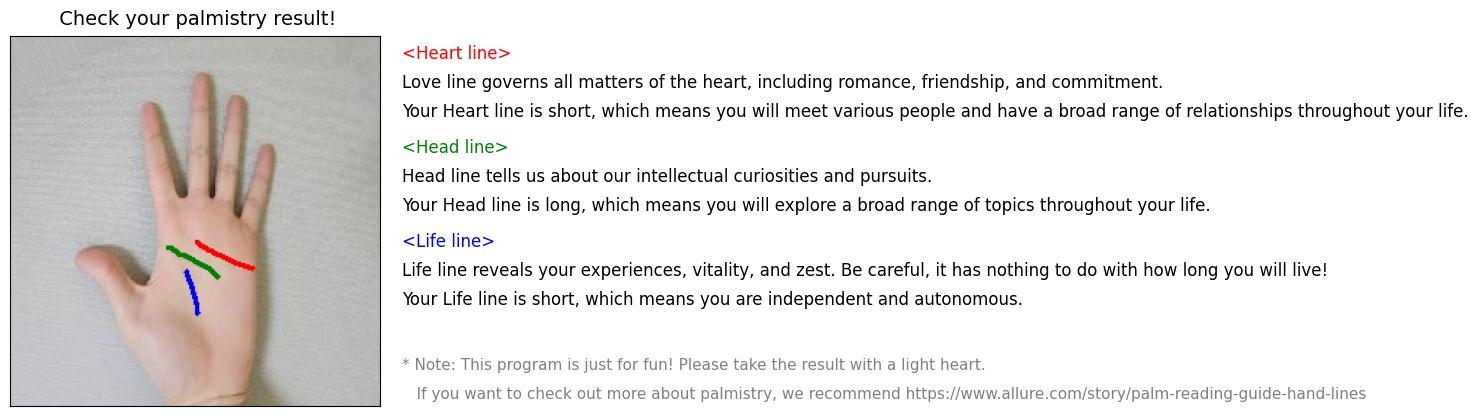

In [26]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/palmistry/code/results/result.jpg'))

In [27]:
%cd /content
!git clone https://github.com/yeonsumia/palmistry.git
%cd /content/palmistry/code
!pip install pillow-heif mediapipe==0.10.14 scikit-image -q
!pip install "protobuf==5.29.1" -q

# patch classification.py: skeletonize() now returns bool, cv2.cvtColor needs uint8
path = '/content/palmistry/code/classification.py'
with open(path, 'r') as f:
    content = f.read()
content = content.replace(
    'skel_img = cv2.cvtColor(skeletonize(img), cv2.COLOR_BGR2GRAY)',
    'skel_img = cv2.cvtColor((skeletonize(img) * 255).astype("uint8"), cv2.COLOR_BGR2GRAY)'
)
content = content.replace(
    'skel_img = cv2.cvtColor(skeletonize(palmline_img), cv2.COLOR_BGR2GRAY)',
    'skel_img = cv2.cvtColor((skeletonize(palmline_img) * 255).astype("uint8"), cv2.COLOR_BGR2GRAY)'
)
with open(path, 'w') as f:
    f.write(content)
print('classification.py patched.')
print()
print('>>> IMPORTANT: Runtime -> Restart session now, then continue from Cell 5. <<<')

/content
fatal: destination path 'palmistry' already exists and is not an empty directory.
/content/palmistry/code
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.14 requires protobuf<5,>=4.25.3, but you have protobuf 5.29.1 which is incompatible.
classification.py patched.

>>> IMPORTANT

In [28]:
%cd /content/palmistry/code
!python read_palm.py --input hand1.jpg

/content/palmistry/code
2026-08-03 13:37:52.064871: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-03 13:37:52.289553: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785764282.730669    7193 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785764282.771890    7193 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: Symb

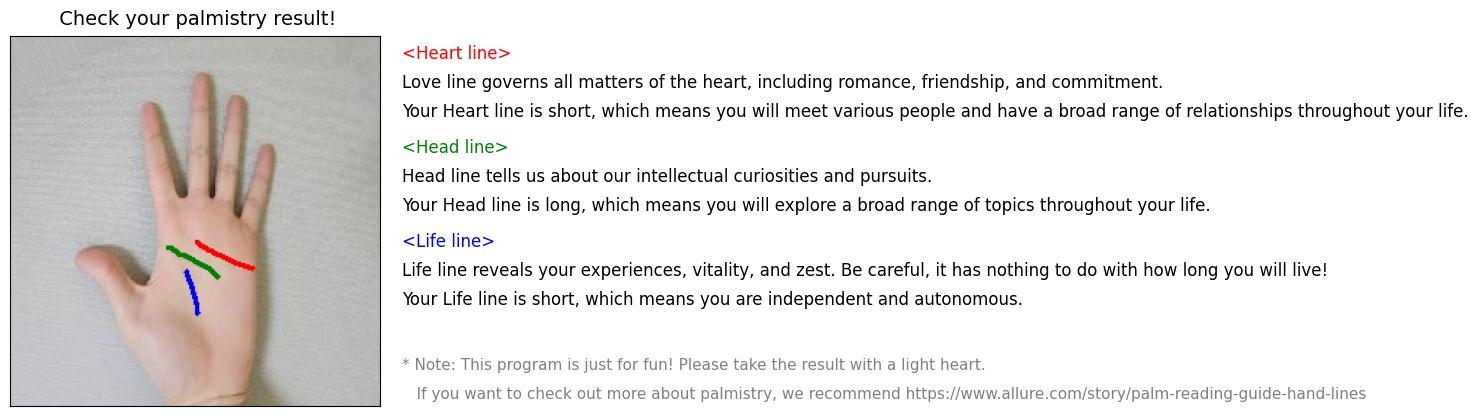

In [29]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/palmistry/code/results/result.jpg'))

In [30]:
import glob, shutil

# ⬇️ EDIT THIS after checking Cell 3's printed tree
HAND_IMAGES_SUBDIR = '/content/hands_data/Hands'  # <-- change if your folder name differs

os.makedirs('/content/palmistry/code/input', exist_ok=True)

all_hand_imgs = glob.glob(f'{HAND_IMAGES_SUBDIR}/*.jpg')
print(f'Found {len(all_hand_imgs)} images')

# copy a small sample first (5 images) to test before running the full batch
sample_imgs = all_hand_imgs[:5]
for img_path in sample_imgs:
    shutil.copy(img_path, '/content/palmistry/code/input/')

print('Copied sample images:', [os.path.basename(p) for p in sample_imgs])

Found 11076 images
Copied sample images: ['Hand_0005086.jpg', 'Hand_0007983.jpg', 'Hand_0008941.jpg', 'Hand_0002832.jpg', 'Hand_0003792.jpg']


In [31]:
%cd /content/palmistry/code
test_image = os.path.basename(sample_imgs[0])
!python read_palm.py --input {test_image}

/content/palmistry/code
2026-08-03 13:38:19.068522: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-03 13:38:19.144386: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785764304.695371    7314 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785764304.738124    7314 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: Symb

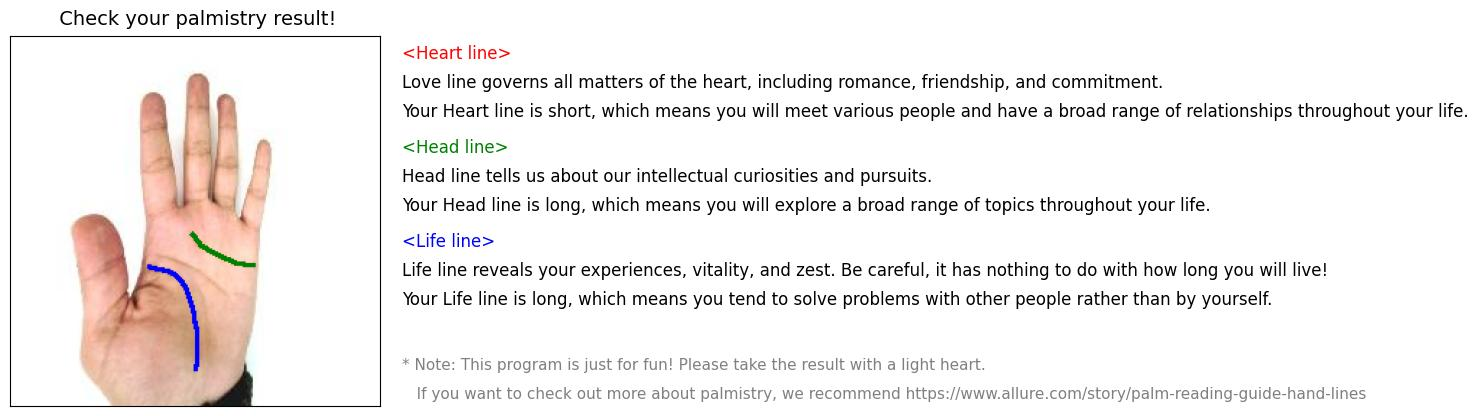

In [32]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/palmistry/code/results/result.jpg'))

In [33]:
import json, urllib.request

# only needed if tarot_data/ has no .json file — skip if you already have one
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/metabismuth/tarot-json/master/tarot.json',
    '/content/tarot_data/tarot.json'
)

# ⬇️ EDIT THIS if your file/path differs
TAROT_JSON_PATH = '/content/tarot_data/tarot.json'

with open(TAROT_JSON_PATH, 'r') as f:
    tarot_data = json.load(f)

# structure varies by which json you loaded (tarot.json is a list, tarot-images.json is often {'cards': [...]})
cards = tarot_data['cards'] if isinstance(tarot_data, dict) and 'cards' in tarot_data else tarot_data
print(f'Loaded {len(cards)} cards')
print(json.dumps(cards[0], indent=2))

Loaded 78 cards
{
  "name": "The Fool",
  "number": "0",
  "arcana": "Major Arcana",
  "suit": null
}


In [34]:
import random

def draw_spread(cards, n=3):
    drawn = random.sample(cards, n)
    reading = []
    for card in drawn:
        reversed_ = random.choice([True, False])
        name = card.get('name') or card.get('name_short') or card.get('card_name', 'Unknown')
        meaning_key = 'meaning_rev' if reversed_ else 'meaning_up'
        meaning = card.get(meaning_key) or card.get('upright_meaning' if not reversed_ else 'reversed_meaning', 'No meaning found in dataset for this field name — check card keys with print(cards[0].keys())')
        reading.append({'card': name, 'reversed': reversed_, 'meaning': meaning})
    return reading

spread = draw_spread(cards, n=3)
for r in spread:
    orientation = 'Reversed' if r['reversed'] else 'Upright'
    print(f"{r['card']} ({orientation}): {r['meaning']}\n")

Eight of Swords (Upright): No meaning found in dataset for this field name — check card keys with print(cards[0].keys())

The Fool (Reversed): No meaning found in dataset for this field name — check card keys with print(cards[0].keys())

Justice (Upright): No meaning found in dataset for this field name — check card keys with print(cards[0].keys())



In [35]:
print(cards[0].keys())

dict_keys(['name', 'number', 'arcana', 'suit'])


In [36]:
import json, urllib.request

# corrected source — this one actually has meanings (previous URL had name/number/arcana only)
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/samia-mnn/tarot_reader1.0/master/tarot.json',
    '/content/tarot_data/tarot.json'
)

with open('/content/tarot_data/tarot.json', 'r') as f:
    cards = json.load(f)

print(f'Loaded {len(cards)} cards')
print(cards[0].keys())

Loaded 78 cards
dict_keys(['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'meanings', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask'])


In [37]:
import random

def draw_spread(cards, n=3):
    drawn = random.sample(cards, n)
    reading = []
    for card in drawn:
        reversed_ = random.choice([True, False])
        name = card['name']
        meaning_list = card['meanings']['shadow'] if reversed_ else card['meanings']['light']
        meaning = '; '.join(meaning_list[:3])  # first 3 keywords-style phrases, keeps it readable
        reading.append({'card': name, 'reversed': reversed_, 'meaning': meaning, 'image_file': card.get('img')})
    return reading

spread = draw_spread(cards, n=3)
for r in spread:
    orientation = 'Reversed' if r['reversed'] else 'Upright'
    print(f"{r['card']} ({orientation}): {r['meaning']}\n")

Ten of Cups (Upright): Having more than you ever dreamed; Being deeply thankful for all you've been given; Recognizing the Hand of God in the gifts the Universe brings your way

Three of Cups (Upright): Celebrating your feelings or connections with others; Expressing joy through song, dance, or physical affection; Working together with others who share your feelings

Two of Wands (Upright): Having a choice; Offering or being offered an option; Seeing the value of another person's approach



In [38]:
!pip install -q google-genai
!pip install -q google-auth==2.49.0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.56.2 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 2.16.0 requires google-auth[requests]<3.0.0,>=2.56.0, but you have google-auth 2.49.0 which is incompatible.


In [1]:
import google.auth
import google.genai

print("google-auth:", google.auth.__version__)
print("Gemini SDK imported successfully")

google-auth: 2.49.0
Gemini SDK imported successfully


In [2]:
from google import genai
from google.colab import userdata

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini client initialized successfully.")

Gemini client initialized successfully.


In [39]:
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents="Reply with exactly: Gemini connection successful"
)

print(response.text)

Gemini connection successful


In [43]:
def generate_tarot_interpretation(question, spread):

    prompt = build_tarot_prompt(
        question,
        spread
    )

    try:
        response = client.models.generate_content(
            model="gemini-3.6-flash",
            contents=prompt
        )

        return response.text

    except Exception as e:
        return f"Gemini API Error: {str(e)}"

In [44]:
import random

def draw_spread(cards, n=3):
    drawn = random.sample(cards, n)
    reading = []

    for card in drawn:
        reversed_ = random.choice([True, False])

        name = card["name"]

        meaning_list = (
            card["meanings"]["shadow"]
            if reversed_
            else card["meanings"]["light"]
        )

        meaning = "; ".join(meaning_list[:3])

        reading.append({
            "card": name,
            "reversed": reversed_,
            "meaning": meaning,
            "image_file": card.get("img")
        })

    return reading

print("draw_spread() loaded")

draw_spread() loaded


In [45]:
print("cards" in globals())

True


In [46]:
# Draw 3 Tarot cards
spread = draw_spread(cards, n=3)

print("🔮 Cards Drawn:\n")

for card in spread:
    orientation = "Reversed" if card["reversed"] else "Upright"

    print(f"🃏 {card['card']} — {orientation}")
    print(f"Meaning: {card['meaning']}")
    print()

🔮 Cards Drawn:

🃏 Eight of Cups — Upright
Meaning: Wanting something better; Blazing your own trail; Realizing there must be more to life

🃏 Wheel of Fortune — Upright
Meaning: Allowing events to unfold; Seeing the larger pattern in everyday events; Trusting your luck

🃏 Justice — Upright
Meaning: Making an objective decision; Weighing an issue carefully before taking action; Appropriately scaling your reaction to a situation



In [79]:
user_question = input("🔮 What would you like guidance about? ")

print("Question:", user_question)

🔮 What would you like guidance about? what should i focus my carrer?
Question: what should i focus my carrer?


In [80]:
def build_tarot_prompt(question, card, palm_reading=""):

    orientation = (
        "Reversed"
        if card["reversed"]
        else "Upright"
    )

    prompt = f"""
You are generating a concise, user-friendly reading
for a two-page AI Palmistry and Tarot PDF.

USER QUESTION:
{question}

PALM READING:
{palm_reading}

TAROT CARD:
{card['card']}

ORIENTATION:
{orientation}

TAROT DATASET MEANING:
{card['meaning']}

Create a concise combined interpretation.

STRICT RULES:
- Write for an ordinary user, not a technical audience.
- Do not use Markdown.
- Do not use #, **, ---, tables, or special formatting.
- Do not repeat the supplied information.
- Do not make guaranteed predictions.
- Keep the COMPLETE response under 350 words.

Return EXACTLY these sections:

OVERALL INSIGHT
Maximum 70 words.

PALM INSIGHT
Maximum 70 words.

TAROT INSIGHT
Maximum 70 words.

WHAT THIS MEANS FOR YOU
Maximum 90 words.

KEY GUIDANCE
Exactly 3 short actionable points.

Do not add another disclaimer.
"""

    return prompt

In [84]:
def generate_tarot_interpretation(question, spread, palm_reading=""):

    # Use the 3rd card as the final Guidance card
    final_card = spread[2]

    prompt = build_tarot_prompt(
        question=question,
        card=final_card,
        palm_reading=palm_reading
    )

    try:
        response = client.models.generate_content(
            model="gemini-3.6-flash",
            contents=prompt
        )

        return response.text

    except Exception as e:
        return f"Gemini API Error: {e}"

In [85]:
palm_text = str(readings) if "readings" in globals() else ""

ai_reading = generate_tarot_interpretation(
    user_question,
    spread,
    palm_text
)

print(ai_reading)

OVERALL INSIGHT
Your career journey right now centers on clarity, alignment, and deliberate choice. By combining practical reflection with objective evaluation, you can identify a path that aligns with your true values. Rather than rushing into a decision, focus on finding a balanced environment where fairness, logic, and integrity are valued. Your best direction lies where your talents meet ethical and structured work.

PALM INSIGHT
Your hand indicates a natural aptitude for logical thinking, organization, and problem-solving. The structures in your palm suggest you thrive when given clear responsibilities and measurable goals. You possess the steady focus needed to weigh complex situations carefully, making you suited for roles that require sound judgment, consistency, and a strong sense of personal accountability.

TAROT INSIGHT
The Justice card highlights the importance of fairness, truth, and rational decision-making in your professional life. It encourages you to step back and ev

In [86]:
!pip install -q reportlab

In [87]:
import os

TAROT_IMAGE_DIR = "/content/tarot_data"

for card in spread:
    image_path = os.path.join(
        TAROT_IMAGE_DIR,
        card["image_file"]
    )

    print(
        card["card"],
        "→",
        image_path,
        "→",
        os.path.exists(image_path)
    )

Eight of Cups → /content/tarot_data/c08.jpg → True
Wheel of Fortune → /content/tarot_data/m10.jpg → True
Justice → /content/tarot_data/m11.jpg → True


In [91]:
import os
import re
import tempfile
from xml.sax.saxutils import escape
from PIL import Image as PILImage
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
from google.colab import files

TAROT_IMAGE_DIR = "/content/tarot_data"
OUTPUT_PATH = "/content/Final_Palm_Tarot_Report.pdf"

def get_tarot_image(card):
    filename = card.get("image_file")

    if not filename:
        return None

    path = os.path.join(TAROT_IMAGE_DIR, filename)

    if not os.path.exists(path):
        return None

    if card.get("reversed", False):
        img = PILImage.open(path)
        img = img.rotate(180, expand=True)

        temp_path = os.path.join(
            tempfile.gettempdir(),
            "reversed_" + filename
        )

        img.save(temp_path)
        return temp_path

    return path


def parse_ai_reading(text):
    sections = {
        "OVERALL INSIGHT": "",
        "PALM INSIGHT": "",
        "TAROT INSIGHT": "",
        "WHAT THIS MEANS FOR YOU": "",
        "KEY GUIDANCE": ""
    }

    current = None

    for line in text.splitlines():
        line = line.strip()

        if not line:
            continue

        line = line.replace("**", "").replace("###", "").strip()
        upper = line.upper()

        if upper in sections:
            current = upper
            continue

        if upper.startswith("DISCLAIMER"):
            current = None
            continue

        if current:
            if sections[current]:
                sections[current] += " " + line
            else:
                sections[current] = line

    return sections


def create_final_pdf(
    hand_image_path,
    question,
    spread,
    ai_reading,
    output_path=OUTPUT_PATH
):
    final_card = spread[2]
    tarot_image_path = get_tarot_image(final_card)
    sections = parse_ai_reading(ai_reading)

    orientation = (
        "Reversed"
        if final_card.get("reversed")
        else "Upright"
    )

    doc = SimpleDocTemplate(
        output_path,
        pagesize=A4,
        rightMargin=38,
        leftMargin=38,
        topMargin=32,
        bottomMargin=32
    )

    styles = getSampleStyleSheet()

    title = ParagraphStyle(
        "Title",
        parent=styles["Title"],
        fontSize=23,
        leading=27,
        alignment=TA_CENTER,
        spaceAfter=6
    )

    subtitle = ParagraphStyle(
        "Subtitle",
        parent=styles["Normal"],
        fontSize=9,
        leading=12,
        alignment=TA_CENTER,
        textColor=colors.HexColor("#666666"),
        spaceAfter=16
    )

    label = ParagraphStyle(
        "Label",
        parent=styles["Normal"],
        fontSize=9,
        leading=12,
        alignment=TA_CENTER,
        textColor=colors.HexColor("#555555"),
        spaceAfter=5
    )

    question_style = ParagraphStyle(
        "Question",
        parent=styles["Normal"],
        fontSize=12,
        leading=16,
        alignment=TA_CENTER,
        spaceAfter=18
    )

    card_name = ParagraphStyle(
        "CardName",
        parent=styles["Heading2"],
        fontSize=15,
        leading=18,
        alignment=TA_CENTER,
        spaceAfter=4
    )

    section = ParagraphStyle(
        "Section",
        parent=styles["Heading2"],
        fontSize=13,
        leading=16,
        textColor=colors.HexColor("#222222"),
        spaceBefore=7,
        spaceAfter=4
    )

    body = ParagraphStyle(
        "Body",
        parent=styles["BodyText"],
        fontSize=9.3,
        leading=13,
        alignment=TA_LEFT,
        textColor=colors.HexColor("#333333"),
        spaceAfter=6
    )

    footer = ParagraphStyle(
        "Footer",
        parent=styles["Normal"],
        fontSize=7.5,
        leading=10,
        alignment=TA_CENTER,
        textColor=colors.HexColor("#777777")
    )

    story = []

    story.append(Paragraph("PALMISTRY & TAROT READING", title))
    story.append(Paragraph("AI-Assisted Personal Reading", subtitle))
    story.append(Paragraph("YOUR QUESTION", label))
    story.append(Paragraph(f'"{escape(question)}"', question_style))

    headings = Table(
        [[
            Paragraph("<b>YOUR PALM</b>", label),
            Paragraph("<b>YOUR TAROT CARD</b>", label)
        ]],
        colWidths=[3.3 * inch, 3.3 * inch]
    )

    headings.setStyle(
        TableStyle([
            ("ALIGN", (0, 0), (-1, -1), "CENTER")
        ])
    )

    story.append(headings)
    story.append(Spacer(1, 6))

    if os.path.exists(hand_image_path):
        palm = Image(
            hand_image_path,
            width=2.7 * inch,
            height=3.6 * inch
        )
    else:
        palm = Paragraph("Palm image unavailable", label)

    if tarot_image_path:
        tarot = Image(
            tarot_image_path,
            width=2.15 * inch,
            height=3.6 * inch
        )
    else:
        tarot = Paragraph("Tarot image unavailable", label)

    images = Table(
        [[palm, tarot]],
        colWidths=[3.3 * inch, 3.3 * inch],
        rowHeights=[3.85 * inch]
    )

    images.setStyle(
        TableStyle([
            ("ALIGN", (0, 0), (-1, -1), "CENTER"),
            ("VALIGN", (0, 0), (-1, -1), "MIDDLE"),
            ("BOX", (0, 0), (0, 0), 0.6, colors.HexColor("#CCCCCC")),
            ("BOX", (1, 0), (1, 0), 0.6, colors.HexColor("#CCCCCC")),
            ("LEFTPADDING", (0, 0), (-1, -1), 10),
            ("RIGHTPADDING", (0, 0), (-1, -1), 10),
            ("TOPPADDING", (0, 0), (-1, -1), 10),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 10)
        ])
    )

    story.append(images)
    story.append(Spacer(1, 12))

    story.append(
        Paragraph(
            escape(final_card["card"]),
            card_name
        )
    )

    story.append(
        Paragraph(
            orientation,
            label
        )
    )

    story.append(Spacer(1, 7))

    story.append(
        Paragraph(
            "<b>Card Meaning</b>",
            label
        )
    )

    story.append(
        Paragraph(
            escape(final_card["meaning"]),
            label
        )
    )

    story.append(Spacer(1, 15))

    story.append(
        Paragraph(
            "Palmistry Computer Vision | Tarot Dataset | Gemini AI",
            footer
        )
    )

    story.append(PageBreak())

    story.append(
        Paragraph(
            "YOUR READING",
            title
        )
    )

    story.append(
        Paragraph(
            "Your personalized palm and Tarot interpretation",
            subtitle
        )
    )

    if sections["OVERALL INSIGHT"]:
        story.append(Paragraph("Overall Insight", section))
        story.append(
            Paragraph(
                escape(sections["OVERALL INSIGHT"]),
                body
            )
        )

    if sections["PALM INSIGHT"]:
        story.append(Paragraph("Palm Insight", section))
        story.append(
            Paragraph(
                escape(sections["PALM INSIGHT"]),
                body
            )
        )

    if sections["TAROT INSIGHT"]:
        story.append(
            Paragraph(
                f"Tarot Insight - {escape(final_card['card'])}",
                section
            )
        )

        story.append(
            Paragraph(
                escape(sections["TAROT INSIGHT"]),
                body
            )
        )

    if sections["WHAT THIS MEANS FOR YOU"]:
        story.append(
            Paragraph(
                "What This Means For You",
                section
            )
        )

        story.append(
            Paragraph(
                escape(sections["WHAT THIS MEANS FOR YOU"]),
                body
            )
        )

    if sections["KEY GUIDANCE"]:
        story.append(
            Paragraph(
                "Key Guidance",
                section
            )
        )

        points = re.split(
            r"(?=\d+\.\s)",
            sections["KEY GUIDANCE"]
        )

        for point in points:
            point = point.strip()

            if not point:
                continue

            point = re.sub(
                r"^\d+\.\s*",
                "",
                point
            )

            story.append(
                Paragraph(
                    "• " + escape(point),
                    body
                )
            )

    story.append(Spacer(1, 10))

    disclaimer = Table(
        [[
            Paragraph(
                "This AI-assisted reading is intended for reflection "
                "and entertainment purposes and should not be treated "
                "as a guaranteed prediction or professional advice.",
                footer
            )
        ]],
        colWidths=[6.55 * inch]
    )

    disclaimer.setStyle(
        TableStyle([
            ("BACKGROUND", (0, 0), (-1, -1), colors.HexColor("#F4F4F4")),
            ("BOX", (0, 0), (-1, -1), 0.5, colors.HexColor("#CCCCCC")),
            ("LEFTPADDING", (0, 0), (-1, -1), 8),
            ("RIGHTPADDING", (0, 0), (-1, -1), 8),
            ("TOPPADDING", (0, 0), (-1, -1), 7),
            ("BOTTOMPADDING", (0, 0), (-1, -1), 7)
        ])
    )

    story.append(disclaimer)

    doc.build(story)

    return output_path


pdf_path = create_final_pdf(
    hand_image_path=img_path,
    question=user_question,
    spread=spread,
    ai_reading=ai_reading
)

files.download(pdf_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>